# Team-Conditioned World Cup DDColor Fine-Tuning

The notebook fine-tunes the CLIP team-conditioned DDColor tiny architecture for World Cup image colorization on a single-GPU CUDA-backed remote Jupyter runtime.


The public DDColorWorldCup repository is cloned inside the session when it is not already available, dependencies are installed inside the notebook, image/team rows are read from `/kaggle/input/worldcup_team_metadata.csv`, and outputs are written under `/kaggle/working`.

In [3]:
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/rubiotelmo/DDColorWorldCup.git"
REPO_ROOT = Path("/kaggle/working/DDColorWorldCup") if Path("/kaggle").exists() else Path.cwd()
if not (REPO_ROOT / "ddcolor").exists():
    REPO_ROOT = Path.cwd() / "DDColorWorldCup"
    if not (REPO_ROOT / "ddcolor").exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_ROOT)], check=True)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
REPO_ROOT

PosixPath('/kaggle/working/DDColorWorldCup')

In [ ]:
# Restart the kernel after this cell if torch is upgraded.
%pip install -q --upgrade torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 --index-url https://download.pytorch.org/whl/cu124
%pip install -q opencv-python-headless scikit-image tqdm huggingface-hub matplotlib transformers optuna


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import csv
import random
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from huggingface_hub import PyTorchModelHubMixin
from skimage import color
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

from basicsr.archs.discriminator_arch import DynamicUNetDiscriminator
from basicsr.losses.losses import ColorfulnessLoss, GANLoss, PerceptualLoss
from basicsr.metrics.colorfulness import calculate_cf
from basicsr.utils.img_util import tensor_lab2rgb
from ddcolor import DDColor
from wcddcolor.model import WorldCupDDColor
from transformers import CLIPTokenizerFast, CLIPTextModelWithProjection
import optuna


DATA_ROOT = Path("/kaggle/input")
DATASET_ROOT = DATA_ROOT / "datasets/oierfernandez2/wc-coloring-2018-2022"
IMAGE_ROOT = DATASET_ROOT / "images/images"
TEAM_CSV = DATASET_ROOT / "metadata.csv"
WORK_DIR = Path("/kaggle/working/wcddcolor_team_runs")
IMG_SIZE = 256
EPOCHS = 3
BATCH_SIZE = 4
LR = 1e-4
SEED = 0
CLIP_MODEL = "openai/clip-vit-base-patch32"
CHROMA_SCALE = 0.8
CHROMA_REG_WEIGHT = 0.01
USE_REGULARIZED_AMP = True
REGULARIZED_AMP_DTYPE = torch.float16
TEST_DIR = Path("/kaggle/input/datasets/oierfernandez2/wc-coloring-2018-2022/test_images/test_images")
TEST_METADATA_CSV = Path("/kaggle/input/datasets/oierfernandez2/wc-coloring-2018-2022/test_images/metadata.csv")
PRED_DIR = WORK_DIR / "test_image_predictions_team" 

assert torch.cuda.is_available(), "A CUDA GPU is required."
device = torch.device("cuda:0")
WORK_DIR.mkdir(parents=True, exist_ok=True)

INPUT_RUN_DIR = Path("/kaggle/input/notebooks/oierfernandez2/wcddcolor/wcddcolor_team_runs")
for name in [
    "checkpoint_team.pt",
    "best_wcddcolor_team_tiny.pt",
    "checkpoint_team_regularized.pt",
    "best_wcddcolor_team_regularized_tiny.pt",
]:
    src = INPUT_RUN_DIR / name
    dst = WORK_DIR / name
    if not dst.exists() and src.exists():
        shutil.copy2(src, dst)
print(sorted(p.name for p in WORK_DIR.glob("*.pt")))

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


['best_wcddcolor_team_regularized_tiny.pt', 'best_wcddcolor_team_tiny.pt', 'checkpoint_team.pt', 'checkpoint_team_regularized.pt']


## 01.- Defining the problem

World Cup image colorization is framed as Lab color prediction conditioned by match teams. The model receives the grayscale lightness channel L, represented as grayscale RGB for DDColor, and two team names whose CLIP text embeddings bias the color decoder toward plausible football kit colors.

The World Cup dataset is imported from `/kaggle/input/datasets/oierfernandez2/wc-coloring-2018-2022`. The CSV uses `path`, `team1`, and `team2` columns, and image paths are resolved relative to the dataset `images/` folder. Images without a CSV row are ignored, and CSV rows with missing team metadata are skipped.

In [6]:
assert TEAM_CSV.exists(), f"Missing metadata CSV: {TEAM_CSV}"
assert IMAGE_ROOT.exists(), f"Missing image folder: {IMAGE_ROOT}"
with TEAM_CSV.open(newline="") as f:
    rows = list(csv.DictReader(f))

assert rows, "The team metadata CSV is empty."
assert {"path", "team1", "team2"} <= set(rows[0]), "CSV must contain path, team1, and team2 columns."
rows = [
    {"path": IMAGE_ROOT / row["path"], "team1": row["team1"].strip(), "team2": row["team2"].strip()}
    for row in rows
    if row["team1"].strip() and row["team2"].strip()
]
assert rows, "No rows with two team names were found."
assert all(row["path"].exists() for row in rows), "Every labeled row needs an existing image path."
random.Random(SEED).shuffle(rows)

n_test = max(1, int(0.1 * len(rows)))
n_val = max(1, int(0.1 * len(rows)))
test_rows = rows[:n_test]
val_rows = rows[n_test:n_test + n_val]
train_rows = rows[n_test + n_val:]

assert train_rows and val_rows and test_rows, "At least three labeled metadata rows are required."
len(train_rows), len(val_rows), len(test_rows)

(120512, 15063, 15063)

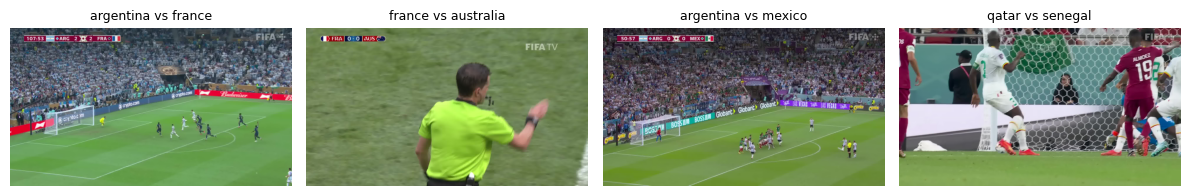

In [7]:
sample_rows = train_rows[:4]
fig, axes = plt.subplots(1, len(sample_rows), figsize=(3 * len(sample_rows), 3))
if len(sample_rows) == 1:
    axes = [axes]
for ax, row in zip(axes, sample_rows):
    img = cv2.cvtColor(cv2.imread(str(row["path"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f'{row["team1"]} vs {row["team2"]}', fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 02.- Choose a measure of success

The training objective follows the DDColor work with AB L1 reconstruction, VGG perceptual similarity, adversarial realism, and colorfulness regularization.

## 03.- Deciding on an evaluation protocol

The evaluation protocol uses PSNR, SSIM, and predicted-image colorfulness on validation and test images, so model selection does not depend on training loss.

## 04.- Preparing the data

Images are resized, randomly flipped during training, decolored through the Lab lightness channel, and separated into L and AB tensors. Each item also returns the two team names used by the team-conditioned color decoder.

In [8]:
class WorldCupTeamLabDataset(Dataset):
    def __init__(self, rows, train=False):
        self.rows = rows
        self.train = train

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        img = cv2.imread(str(row["path"]), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        if self.train and random.random() < 0.5:
            img = np.ascontiguousarray(img[:, ::-1])
        lab = color.rgb2lab(img.astype(np.float32) / 255.0).astype(np.float32)
        l = torch.from_numpy(lab[:, :, :1].transpose(2, 0, 1))
        ab = torch.from_numpy(lab[:, :, 1:].transpose(2, 0, 1))
        return l, ab, row["team1"], row["team2"]


train_loader = DataLoader(WorldCupTeamLabDataset(train_rows, True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
train_eval_rows = train_rows[:1024]
val_eval_rows = val_rows[:2048]
train_eval_loader = DataLoader(WorldCupTeamLabDataset(train_eval_rows), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader = DataLoader(WorldCupTeamLabDataset(val_eval_rows), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(WorldCupTeamLabDataset(test_rows), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [9]:
def l_to_rgb(l):
    return tensor_lab2rgb(torch.cat([l, torch.zeros_like(l), torch.zeros_like(l)], dim=1))


def lab_to_rgb(l, ab):
    return tensor_lab2rgb(torch.cat([l, ab], dim=1))


@torch.no_grad()
def evaluate(model, loader, chroma_scale=1.0, use_amp=False):
    model.eval()
    psnr, ssim, cf = [], [], []
    for l, ab, team1, team2 in loader:
        l, ab = l.to(device), ab.to(device)
        teams = list(zip(team1, team2))
    
        gray_rgb = l_to_rgb(l.float())

        with torch.amp.autocast("cuda", enabled=use_amp, dtype=REGULARIZED_AMP_DTYPE):
            pred_ab = model(gray_rgb, teams=teams) * chroma_scale

        pred_rgb = lab_to_rgb(l.float(), pred_ab.float()).cpu().clamp(0, 1)
        gt_rgb = lab_to_rgb(l.float(), ab.float()).cpu().clamp(0, 1)
        
        for pred, gt in zip(pred_rgb, gt_rgb):
            pred = pred.permute(1, 2, 0).numpy()
            gt = gt.permute(1, 2, 0).numpy()
            psnr.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim.append(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))
            cf.append(calculate_cf((pred[:, :, ::-1] * 255).round().astype(np.uint8)))
    return {"psnr": float(np.mean(psnr)), "ssim": float(np.mean(ssim)), "colorfulness": float(np.mean(cf))}


## 05.- Fine tune the team-conditioned DDColor tiny model

The DDColor tiny checkpoint is loaded from Hugging Face and copied into `WorldCupDDColor` with `strict=False`, leaving the CLIP projection and team cross-attention layers freshly initialized. Fine-tuning runs directly in this notebook on `cuda:0` with the same losses, optimizers, checkpoint names, and checkpoint state keys used by the previous DDP training cell.


In [10]:
class DDColorHF(DDColor, PyTorchModelHubMixin):
    def __init__(self, config=None, **kwargs):
        if isinstance(config, dict):
            kwargs = {**config, **kwargs}
        super().__init__(**kwargs)


base_model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny")
model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
model.load_state_dict(base_model.state_dict(), strict=False)
for p in model.encoder.parameters():
    p.requires_grad = False

l, ab, team1, team2 = next(iter(train_loader))
with torch.no_grad():
    y = model(l_to_rgb(l[:1].to(device)), teams=list(zip(team1[:1], team2[:1])))
assert y.shape == (1, 2, IMG_SIZE, IMG_SIZE)
del model, base_model, l, ab, y
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

In [11]:
CLIPTokenizerFast.from_pretrained(CLIP_MODEL)
CLIPTextModelWithProjection.from_pretrained(CLIP_MODEL)

print("CLIP cached")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

CLIP cached


In [12]:
base_model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny")
model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
model.load_state_dict(base_model.state_dict(), strict=False)
del base_model
for p in model.encoder.parameters():
    p.requires_grad = False

disc = DynamicUNetDiscriminator(n_channels=3, nf=64).to(device)
pixel_loss = torch.nn.L1Loss()
perceptual_loss = PerceptualLoss(
    layer_weights={"conv1_1": 0.0625, "conv2_1": 0.125, "conv3_1": 0.25, "conv4_1": 0.5, "conv5_1": 1.0},
    vgg_type="vgg16_bn",
    use_input_norm=True,
    range_norm=False,
    perceptual_weight=5.0,
    style_weight=0,
    criterion="l1",
).to(device)
gan_loss = GANLoss("vanilla", loss_weight=1.0).to(device)
color_loss = ColorfulnessLoss(loss_weight=0.5).to(device)
opt_g = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LR, weight_decay=0.01, betas=(0.9, 0.99))
opt_d = torch.optim.Adam(disc.parameters(), lr=LR, betas=(0.9, 0.99))

start_epoch = 0
best_ssim = -1.0
history = []
checkpoint_path = WORK_DIR / "checkpoint_team.pt"
best_path = WORK_DIR / "best_wcddcolor_team_tiny.pt"
if checkpoint_path.exists():
    state = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state["model"], strict=False)
    disc.load_state_dict(state["discriminator"])
    opt_g.load_state_dict(state["opt_g"])
    opt_d.load_state_dict(state["opt_d"])
    start_epoch = state["epoch"] + 1
    best_ssim = state["best_ssim"]
    history = state.get("history", [])

for epoch in range(start_epoch, EPOCHS):
    model.train()
    model.encoder.eval()
    disc.train()
    running_g, running_d = 0.0, 0.0
    for l, ab, team1, team2 in tqdm(train_loader, desc=f"epoch {epoch + 1}/{EPOCHS}"):
        l, ab = l.to(device), ab.to(device)
        teams = list(zip(team1, team2))
        gray_rgb = l_to_rgb(l)
        gt_rgb = lab_to_rgb(l, ab)

        for p in disc.parameters():
            p.requires_grad_(False)
        opt_g.zero_grad(set_to_none=True)
        pred_ab = model(gray_rgb, teams=teams)
        pred_rgb = lab_to_rgb(l, pred_ab)
        loss_perc, _ = perceptual_loss(pred_rgb, gt_rgb)
        loss_g = 0.1 * pixel_loss(pred_ab, ab) + loss_perc + gan_loss(disc(pred_rgb), True, is_disc=False) + color_loss(pred_rgb)
        loss_g.backward()
        opt_g.step()

        for p in disc.parameters():
            p.requires_grad_(True)
        opt_d.zero_grad(set_to_none=True)
        loss_d = gan_loss(disc(gt_rgb), True, is_disc=True) + gan_loss(disc(pred_rgb.detach()), False, is_disc=True)
        loss_d.backward()
        opt_d.step()
        running_g += loss_g.item()
        running_d += loss_d.item()

    train_metrics = evaluate(model, train_eval_loader)
    val_metrics = evaluate(model, val_loader)
    epoch_history = {
        "epoch": epoch + 1,
        "g_loss": running_g / len(train_loader),
        "d_loss": running_d / len(train_loader),
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    history.append(epoch_history)
    if val_metrics["ssim"] > best_ssim:
        best_ssim = val_metrics["ssim"]
        torch.save({"model": model.state_dict(), "epoch": epoch, "metrics": val_metrics}, best_path)
    torch.save({
        "model": model.state_dict(), "discriminator": disc.state_dict(),
        "opt_g": opt_g.state_dict(), "opt_d": opt_d.state_dict(), "epoch": epoch,
        "best_ssim": best_ssim, "metrics": val_metrics, "history": history,
    }, checkpoint_path)
    print(epoch_history)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

In [13]:
checkpoint_path = WORK_DIR / "checkpoint_team.pt"
best_path = WORK_DIR / "best_wcddcolor_team_tiny.pt"
history = torch.load(checkpoint_path, map_location="cpu").get("history", [])


Learning curves compare training and validation metrics across epochs so overfitting can be inspected after fine-tuning.

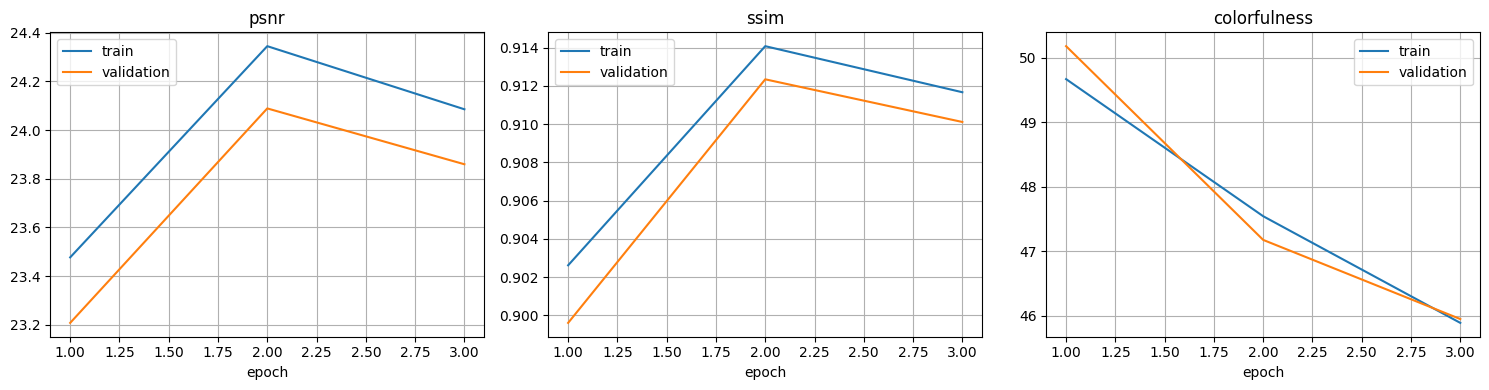

In [14]:
epochs = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["psnr", "ssim", "colorfulness"]):
    ax.plot(epochs, [row[f"train_{metric}"] for row in history], label="train")
    ax.plot(epochs, [row[f"val_{metric}"] for row in history], label="validation")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.grid(True)
    ax.legend()
fig.tight_layout()
fig.savefig(WORK_DIR / "learning_curves_team.png", dpi=150)
plt.show()

## 06.- Regularized fine tuning

A second fine-tuning run starts again from the DDColor tiny Hugging Face checkpoint, keeping the original fine-tuned run unchanged for comparison. This regularized run keeps the same data split and objective, but scales predicted chroma, penalizes large raw `AB` predictions, and freezes the encoder plus the first two decoder blocks.


In [15]:
regularized_checkpoint_path = WORK_DIR / "checkpoint_team_regularized.pt"
regularized_best_path = WORK_DIR / "best_wcddcolor_team_regularized_tiny.pt"

base_model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny")
regularized_model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
regularized_model.load_state_dict(base_model.state_dict(), strict=False)
del base_model
for p in regularized_model.encoder.parameters():
    p.requires_grad = False
for p in regularized_model.decoder.layers[:2].parameters():
    p.requires_grad = False

regularized_disc = DynamicUNetDiscriminator(n_channels=3, nf=64).to(device)
regularized_pixel_loss = torch.nn.L1Loss()
regularized_perceptual_loss = PerceptualLoss(
    layer_weights={"conv1_1": 0.0625, "conv2_1": 0.125, "conv3_1": 0.25, "conv4_1": 0.5, "conv5_1": 1.0},
    vgg_type="vgg16_bn",
    use_input_norm=True,
    range_norm=False,
    perceptual_weight=5.0,
    style_weight=0,
    criterion="l1",
).to(device)
regularized_gan_loss = GANLoss("vanilla", loss_weight=1.0).to(device)
regularized_color_loss = ColorfulnessLoss(loss_weight=0.5).to(device)
regularized_opt_g = torch.optim.AdamW(
    (p for p in regularized_model.parameters() if p.requires_grad),
    lr=LR,
    weight_decay=0.01,
    betas=(0.9, 0.99),
)
regularized_opt_d = torch.optim.Adam(regularized_disc.parameters(), lr=LR, betas=(0.9, 0.99))
regularized_sched_g = torch.optim.lr_scheduler.CosineAnnealingLR(regularized_opt_g, T_max=EPOCHS)
regularized_sched_d = torch.optim.lr_scheduler.CosineAnnealingLR(regularized_opt_d, T_max=EPOCHS)
regularized_scaler = torch.amp.GradScaler("cuda", enabled=USE_REGULARIZED_AMP)

regularized_start_epoch = 0
regularized_best_ssim = -1.0
regularized_history = []
if regularized_checkpoint_path.exists():
    state = torch.load(regularized_checkpoint_path, map_location=device)
    regularized_model.load_state_dict(state["model"], strict=False)
    regularized_disc.load_state_dict(state["discriminator"])
    regularized_opt_g.load_state_dict(state["opt_g"])
    regularized_opt_d.load_state_dict(state["opt_d"])
    if "sched_g" in state:
        regularized_sched_g.load_state_dict(state["sched_g"])
    if "sched_d" in state:
        regularized_sched_d.load_state_dict(state["sched_d"])
    if "scaler" in state:
        regularized_scaler.load_state_dict(state["scaler"])
    regularized_start_epoch = state["epoch"] + 1
    regularized_best_ssim = state["best_ssim"]
    regularized_history = state.get("history", [])

for epoch in range(regularized_start_epoch, EPOCHS):
    regularized_model.train()
    regularized_model.encoder.eval()
    regularized_model.decoder.layers[:2].eval()
    regularized_disc.train()
    running_g, running_d = 0.0, 0.0
    for l, ab, team1, team2 in tqdm(train_loader, desc=f"regularized epoch {epoch + 1}/{EPOCHS}"):
        l, ab = l.to(device), ab.to(device)
        teams = list(zip(team1, team2))
        gray_rgb = l_to_rgb(l)
        gt_rgb = lab_to_rgb(l.float(), ab.float())

        for p in regularized_disc.parameters():
            p.requires_grad_(False)
        regularized_opt_g.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_REGULARIZED_AMP, dtype=REGULARIZED_AMP_DTYPE):
            raw_pred_ab = regularized_model(gray_rgb, teams=teams)
        pred_ab = (raw_pred_ab * CHROMA_SCALE).float()
        pred_rgb = lab_to_rgb(l.float(), pred_ab)
        chroma_reg = raw_pred_ab.float().pow(2).mean()
        with torch.amp.autocast("cuda", enabled=USE_REGULARIZED_AMP, dtype=REGULARIZED_AMP_DTYPE):
            loss_perc, _ = regularized_perceptual_loss(pred_rgb, gt_rgb)
            loss_g = (
                0.1 * regularized_pixel_loss(pred_ab, ab.float())
                + loss_perc
                + regularized_gan_loss(regularized_disc(pred_rgb), True, is_disc=False)
                + regularized_color_loss(pred_rgb)
                + CHROMA_REG_WEIGHT * chroma_reg
            )
        regularized_scaler.scale(loss_g).backward()
        regularized_scaler.step(regularized_opt_g)

        for p in regularized_disc.parameters():
            p.requires_grad_(True)
        regularized_opt_d.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_REGULARIZED_AMP, dtype=REGULARIZED_AMP_DTYPE):
            loss_d = regularized_gan_loss(regularized_disc(gt_rgb), True, is_disc=True) + regularized_gan_loss(
                regularized_disc(pred_rgb.detach()), False, is_disc=True
            )
        regularized_scaler.scale(loss_d).backward()
        regularized_scaler.step(regularized_opt_d)
        regularized_scaler.update()
        running_g += loss_g.item()
        running_d += loss_d.item()

    regularized_sched_g.step()
    regularized_sched_d.step()
    train_metrics = evaluate(
        regularized_model,
        train_eval_loader,
        chroma_scale=CHROMA_SCALE,
        use_amp=USE_REGULARIZED_AMP,
    )
    val_metrics = evaluate(
        regularized_model,
        val_loader,
        chroma_scale=CHROMA_SCALE,
        use_amp=USE_REGULARIZED_AMP,
    )
    epoch_history = {
        "epoch": epoch + 1,
        "g_loss": running_g / len(train_loader),
        "d_loss": running_d / len(train_loader),
        "lr_g": regularized_sched_g.get_last_lr()[0],
        "lr_d": regularized_sched_d.get_last_lr()[0],
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }
    regularized_history.append(epoch_history)
    if val_metrics["ssim"] > regularized_best_ssim:
        regularized_best_ssim = val_metrics["ssim"]
        torch.save({"model": regularized_model.state_dict(), "epoch": epoch, "metrics": val_metrics}, regularized_best_path)
    torch.save({
        "model": regularized_model.state_dict(), "discriminator": regularized_disc.state_dict(),
        "opt_g": regularized_opt_g.state_dict(), "opt_d": regularized_opt_d.state_dict(),
        "sched_g": regularized_sched_g.state_dict(), "sched_d": regularized_sched_d.state_dict(),
        "scaler": regularized_scaler.state_dict(), "epoch": epoch,
        "best_ssim": regularized_best_ssim, "metrics": val_metrics, "history": regularized_history,
    }, regularized_checkpoint_path)
    print(epoch_history)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

regularized epoch 2/3:   0%|          | 0/30128 [00:00<?, ?it/s]

{'epoch': 2, 'g_loss': 9.62353573580467, 'd_loss': 0.47989431319031733, 'lr_g': 2.5000000000000015e-05, 'lr_d': 2.5000000000000015e-05, 'train_psnr': 21.144139193467417, 'train_ssim': 0.8800769448280334, 'train_colorfulness': 36.139657139053554, 'val_psnr': 20.98951114246787, 'val_ssim': 0.8790245652198792, 'val_colorfulness': 36.000290287584335}


regularized epoch 3/3:   0%|          | 0/30128 [00:00<?, ?it/s]

{'epoch': 3, 'g_loss': 9.901138747697553, 'd_loss': 0.5031090017720006, 'lr_g': 0.0, 'lr_d': 0.0, 'train_psnr': 20.645284719404486, 'train_ssim': 0.8712952136993408, 'train_colorfulness': 35.80040699412022, 'val_psnr': 20.49992920521461, 'val_ssim': 0.8696147203445435, 'val_colorfulness': 35.698198606647765}


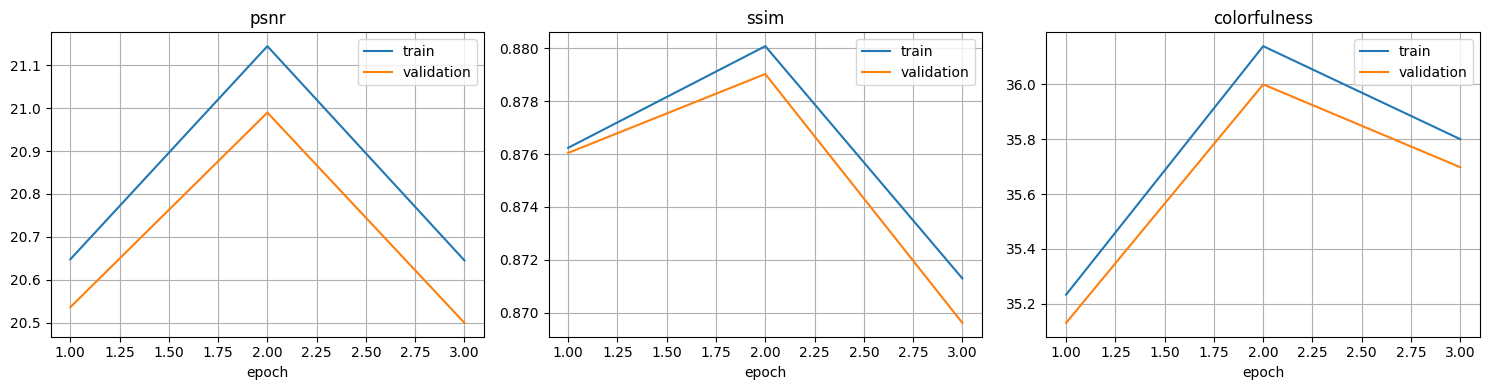

In [16]:
regularized_history = torch.load(regularized_checkpoint_path, map_location="cpu").get("history", [])
regularized_epochs = [row["epoch"] for row in regularized_history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["psnr", "ssim", "colorfulness"]):
    ax.plot(regularized_epochs, [row[f"train_{metric}"] for row in regularized_history], label="train")
    ax.plot(regularized_epochs, [row[f"val_{metric}"] for row in regularized_history], label="validation")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.grid(True)
    ax.legend()
fig.tight_layout()
fig.savefig(WORK_DIR / "learning_curves_team_regularized.png", dpi=150)
plt.show()


## 07.- Hyperparameter Tuning PoC with Optuna

This section runs a deliberately tiny Optuna hyperparameter tuning campaign on 1% of the training and validation data. The goal is not to find the final best model, but to demonstrate that the tuning workflow is understood:

- define a search space,
- train a fresh model per trial,
- evaluate each trial on held-out validation data,
- select the best configuration by validation SSIM,
- save a compact results table.

To keep this fast, the PoC uses only pixel L1 loss and a small number of batches per trial. The full GAN/perceptual/colorfulness training loop remains separate.

In [23]:
TUNE_FRACTION = 0.01
TUNE_EPOCHS = 1
TUNE_MAX_BATCHES = 8
TUNE_VAL_MAX_BATCHES = 4
N_TRIALS = 5

tune_train_rows = train_rows[:max(1, int(len(train_rows) * TUNE_FRACTION))]
tune_val_rows = val_rows[:max(1, int(len(val_rows) * TUNE_FRACTION))]

tune_train_loader = DataLoader(
    WorldCupTeamLabDataset(tune_train_rows, train=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

tune_val_loader = DataLoader(
    WorldCupTeamLabDataset(tune_val_rows, train=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(len(tune_train_rows), len(tune_val_rows))

1205 150


In [24]:
@torch.no_grad()
def evaluate_tiny(model, loader, chroma_scale=1.0):
    model.eval()
    scores = []

    for batch_idx, (l, ab, team1, team2) in enumerate(loader):
        if batch_idx >= TUNE_VAL_MAX_BATCHES:
            break

        l, ab = l.to(device), ab.to(device)
        teams = list(zip(team1, team2))

        gray_rgb = l_to_rgb(l.float())
        pred_ab = model(gray_rgb, teams=teams) * chroma_scale

        pred_rgb = lab_to_rgb(l.float(), pred_ab.float()).cpu().clamp(0, 1)
        gt_rgb = lab_to_rgb(l.float(), ab.float()).cpu().clamp(0, 1)

        for pred, gt in zip(pred_rgb, gt_rgb):
            pred = pred.permute(1, 2, 0).numpy()
            gt = gt.permute(1, 2, 0).numpy()
            scores.append(structural_similarity(gt, pred, channel_axis=2, data_range=1.0))

    return float(np.mean(scores))

In [25]:
class DDColorHF(DDColor, PyTorchModelHubMixin):
    def __init__(self, config=None, **kwargs):
        if isinstance(config, dict):
            kwargs = {**config, **kwargs}
        super().__init__(**kwargs)

In [26]:
def objective(trial):
    lr = trial.suggest_float("lr", 3e-5, 3e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 5e-2, log=True)
    chroma_scale = trial.suggest_float("chroma_scale", 0.6, 1.1)
    freeze_decoder_blocks = trial.suggest_int("freeze_decoder_blocks", 0, 2)

    base_model = DDColorHF.from_pretrained("piddnad/ddcolor_paper_tiny")
    model = WorldCupDDColor(
        encoder_name="convnext-t",
        input_size=(IMG_SIZE, IMG_SIZE),
        num_output_channels=2,
        num_queries=100,
        last_norm="Spectral",
        do_normalize=False,
    ).to(device)

    model.load_state_dict(base_model.state_dict(), strict=False)
    del base_model

    for p in model.encoder.parameters():
        p.requires_grad = False

    if freeze_decoder_blocks:
        for p in model.decoder.layers[:freeze_decoder_blocks].parameters():
            p.requires_grad = False

    opt = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=lr,
        weight_decay=weight_decay,
    )
    loss_fn = torch.nn.L1Loss()

    for epoch in range(TUNE_EPOCHS):
        model.train()
        model.encoder.eval()

        for batch_idx, (l, ab, team1, team2) in enumerate(tune_train_loader):
            if batch_idx >= TUNE_MAX_BATCHES:
                break

            l, ab = l.to(device), ab.to(device)
            teams = list(zip(team1, team2))

            gray_rgb = l_to_rgb(l.float())
            pred_ab = model(gray_rgb, teams=teams) * chroma_scale
            loss = loss_fn(pred_ab, ab)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

    score = evaluate_tiny(model, tune_val_loader, chroma_scale)

    del model
    torch.cuda.empty_cache()

    return score

In [27]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("Best SSIM:", study.best_value)
print("Best params:", study.best_params)

[I 2026-06-05 15:41:23,187] A new study created in memory with name: no-name-b9033559-bf6b-40e7-9a45-691a478ac981


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

Best SSIM: 0.9100223183631897
Best params: {'lr': 0.0002972210043074552, 'weight_decay': 0.00033698002032704334, 'chroma_scale': 0.6032844640547869, 'freeze_decoder_blocks': 2}


In [28]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_chroma_scale,params_freeze_decoder_blocks,params_lr,params_weight_decay,state
0,0,0.901711,2026-06-05 15:41:23.188716,2026-06-05 15:41:33.125072,0 days 00:00:09.936356,0.909016,1,0.000159,0.000110,COMPLETE
1,1,0.909798,2026-06-05 15:41:33.127207,2026-06-05 15:41:42.159178,0 days 00:00:09.031971,0.701485,1,0.000173,0.000236,COMPLETE
2,2,0.896331,2026-06-05 15:41:42.161233,2026-06-05 15:41:51.265215,0 days 00:00:09.103982,0.718132,2,0.000051,0.000114,COMPLETE
3,3,0.887495,2026-06-05 15:41:51.267632,2026-06-05 15:42:00.258584,0 days 00:00:08.990952,0.899240,1,0.000035,0.012881,COMPLETE
4,4,0.910022,2026-06-05 15:42:00.260745,2026-06-05 15:42:09.261652,0 days 00:00:09.000907,0.603284,2,0.000297,0.000337,COMPLETE


## 08.- Final model testing

The best original checkpoint and the best regularized checkpoint are evaluated on the held-out test partition. A compact grid is also saved for the original checkpoint to preserve the previous testing artifact.


In [17]:
model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
best = torch.load(best_path, map_location=device)
model.load_state_dict(best["model"], strict=False)
test_metrics = evaluate(model, test_loader)
print({"original": test_metrics})

regularized_model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
regularized_best = torch.load(regularized_best_path, map_location=device)
regularized_model.load_state_dict(regularized_best["model"], strict=False)
regularized_test_metrics = evaluate(regularized_model, test_loader, chroma_scale=CHROMA_SCALE, use_amp=USE_REGULARIZED_AMP)
print({"regularized": regularized_test_metrics})

l, ab, team1, team2 = next(iter(test_loader))
l, ab = l[:4].to(device), ab[:4].to(device)
teams = list(zip(team1[:4], team2[:4]))
model.eval()
with torch.no_grad():
    gray_rgb_gpu = l_to_rgb(l)
    pred_ab = model(gray_rgb_gpu, teams=teams)
    gray_rgb = gray_rgb_gpu.cpu().clamp(0, 1)
    pred_rgb = lab_to_rgb(l, pred_ab).cpu().clamp(0, 1)
    gt_rgb = lab_to_rgb(l, ab).cpu().clamp(0, 1)

grid = make_grid(torch.cat([gray_rgb, pred_rgb, gt_rgb], dim=0), nrow=l.size(0))
save_image(grid, WORK_DIR / "test_examples_team.png")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

{'original': {'psnr': 24.154663213215656, 'ssim': 0.9130628108978271, 'colorfulness': 47.74919366278492}}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

{'regularized': {'psnr': 21.021405936868018, 'ssim': 0.8793677091598511, 'colorfulness': 36.14525253496403}}


## 09.- Real-image validation

Real World Cup images with metadata are used as visual validation after both fine-tuning runs. The grid compares grayscale input, the original fine-tuned prediction, and the regularized prediction.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.la

Validating real images:   0%|          | 0/6 [00:00<?, ?it/s]

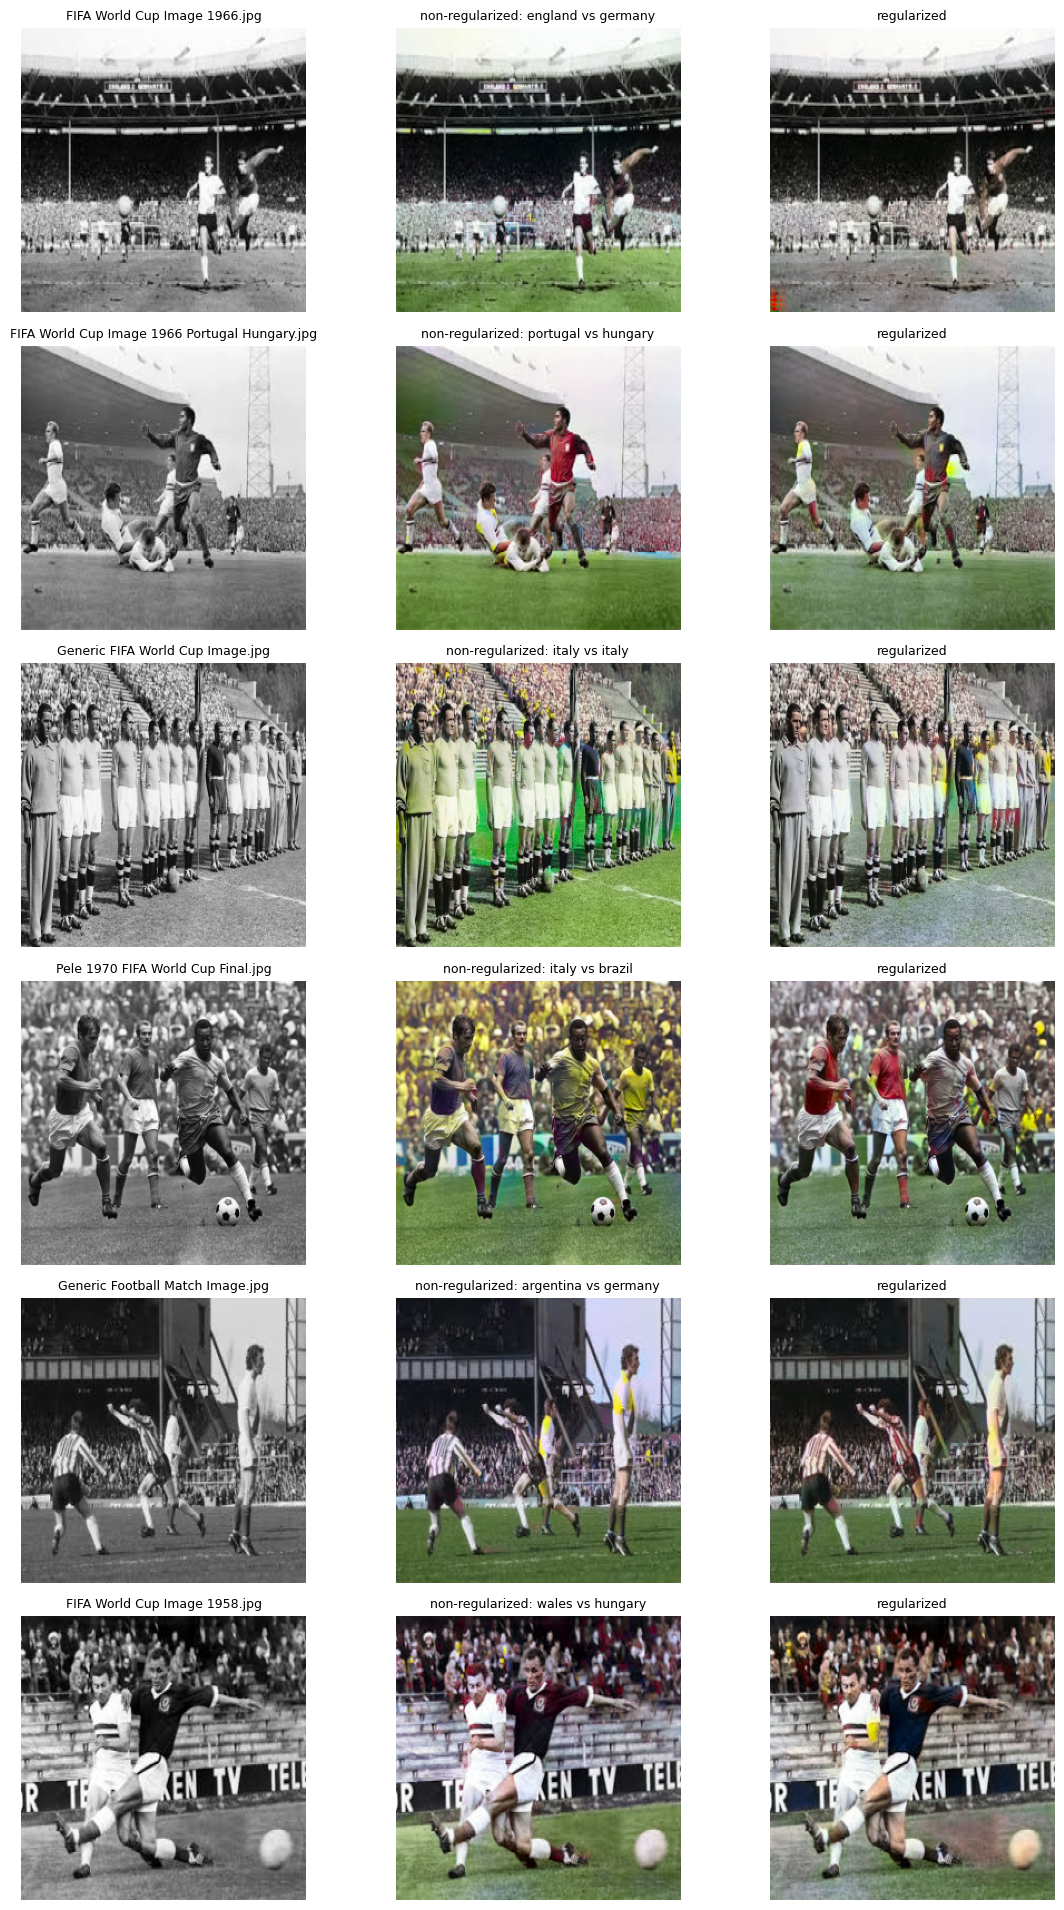

Saved 6 non-regularized predictions to: /kaggle/working/wcddcolor_team_runs/test_image_predictions_team
Saved 6 regularized predictions to: /kaggle/working/wcddcolor_team_runs/test_image_predictions_team_regularized
Saved validation grid to: /kaggle/working/wcddcolor_team_runs/real_image_validation_team_grid.png


In [20]:
PRED_DIR.mkdir(parents=True, exist_ok=True)
REGULARIZED_PRED_DIR = WORK_DIR / "test_image_predictions_team_regularized"
REGULARIZED_PRED_DIR.mkdir(parents=True, exist_ok=True)

with TEST_METADATA_CSV.open(newline="") as f:
    test_rows = list(csv.DictReader(f))
assert test_rows, f"No metadata rows found in {TEST_METADATA_CSV}"

model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
best = torch.load(best_path, map_location=device)
model.load_state_dict(best["model"], strict=False)
model.eval()

regularized_model = WorldCupDDColor(
    encoder_name="convnext-t",
    input_size=(IMG_SIZE, IMG_SIZE),
    num_output_channels=2,
    num_queries=100,
    last_norm="Spectral",
    do_normalize=False,
).to(device)
regularized_best = torch.load(regularized_best_path, map_location=device)
regularized_model.load_state_dict(regularized_best["model"], strict=False)
regularized_model.eval()

results = []

with torch.no_grad():
    for row in tqdm(test_rows, desc="Validating real images"):
        path = TEST_DIR / Path(row["path"]).relative_to("test_images")
        img = cv2.imread(str(path), cv2.IMREAD_COLOR)
        assert img is not None, f"Could not read image: {path}"

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

        lab = color.rgb2lab(img.astype(np.float32) / 255.0).astype(np.float32)
        l = torch.from_numpy(lab[:, :, :1].transpose(2, 0, 1)).unsqueeze(0).to(device)
        teams = [(row["team1"].strip(), row["team2"].strip())]
        gray_rgb_gpu = l_to_rgb(l)

        original_rgb = lab_to_rgb(l, model(gray_rgb_gpu, teams=teams)).cpu().clamp(0, 1)[0]
        with torch.amp.autocast("cuda", enabled=USE_REGULARIZED_AMP, dtype=REGULARIZED_AMP_DTYPE):
            regularized_ab = regularized_model(gray_rgb_gpu, teams=teams) * CHROMA_SCALE
        regularized_rgb = lab_to_rgb(l.float(), regularized_ab.float()).cpu().clamp(0, 1)[0]
        gray_rgb = gray_rgb_gpu.cpu().clamp(0, 1)[0]

        original_img = (original_rgb.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
        regularized_img = (regularized_rgb.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
        cv2.imwrite(str(PRED_DIR / f"{path.stem}.png"), cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(REGULARIZED_PRED_DIR / f"{path.stem}.png"), cv2.cvtColor(regularized_img, cv2.COLOR_RGB2BGR))

        results.append({
            "path": path,
            "teams": teams[0],
            "gray": gray_rgb.permute(1, 2, 0).numpy(),
            "non-regularized": original_rgb.permute(1, 2, 0).numpy(),
            "regularized": regularized_rgb.permute(1, 2, 0).numpy(),
        })

fig, axes = plt.subplots(len(results), 3, figsize=(12, 3.2 * len(results)), squeeze=False)

for row_axes, item in zip(axes, results):
    team1, team2 = item["teams"]
    row_axes[0].imshow(item["gray"])
    row_axes[0].set_title(item["path"].name, fontsize=9)
    row_axes[0].axis("off")
    row_axes[1].imshow(item["non-regularized"])
    row_axes[1].set_title(f"non-regularized: {team1} vs {team2}", fontsize=9)
    row_axes[1].axis("off")
    row_axes[2].imshow(item["regularized"])
    row_axes[2].set_title("regularized", fontsize=9)
    row_axes[2].axis("off")

fig.tight_layout()
grid_path = WORK_DIR / "real_image_validation_team_grid.png"
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {len(results)} non-regularized predictions to: {PRED_DIR}")
print(f"Saved {len(results)} regularized predictions to: {REGULARIZED_PRED_DIR}")
print(f"Saved validation grid to: {grid_path}")
